# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
133,-0.041840,0.050680,-0.053630,-0.040099,-0.084126,-0.071772,-0.002903,-0.039493,-0.072133,-0.030072,83.0
57,-0.027310,-0.044642,-0.063330,-0.050427,-0.089630,-0.104340,0.052322,-0.076395,-0.056153,-0.067351,37.0
145,-0.041840,-0.044642,0.128521,0.063187,-0.033216,-0.032629,0.011824,-0.039493,-0.015999,-0.050783,259.0
404,-0.016412,-0.044642,0.054152,0.070072,-0.033216,-0.027931,0.008142,-0.039493,-0.027129,-0.009362,293.0
22,-0.085430,-0.044642,-0.004050,-0.009113,-0.002945,0.007767,0.022869,-0.039493,-0.061176,-0.013504,68.0
433,-0.027310,-0.044642,-0.060097,-0.029770,0.046589,0.019980,0.122273,-0.039493,-0.051404,-0.009362,72.0
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912,179.0
167,0.070769,-0.044642,0.069241,0.037950,0.021822,0.001504,-0.036038,0.039106,0.077637,0.106617,220.0
343,-0.020045,-0.044642,0.018584,0.090729,0.003935,0.008707,0.037595,-0.039493,-0.057803,0.007207,113.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [ ]:
# Calcular valores faltantes por columna
valores_faltantes    = data.isnull().sum()
print("Valores faltantes por columna:")
print(valores_faltantes)

# Total general
total_faltantes      = valores_faltantes.sum()
print(f"\nTotal de valores faltantes en el dataset: {total_faltantes}")

# Porcentaje por columna
porcentaje_faltantes = (data.isnull().sum() / len(data)) * 100
print("\nPorcentaje de valores faltantes por columna:")
print(porcentaje_faltantes.round(2))

Valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

Total de valores faltantes en el dataset: 88

Porcentaje de valores faltantes por columna:
age       0.00
sex       0.00
bmi       9.95
bp        9.95
s1        0.00
s2        0.00
s3        0.00
s4        0.00
s5        0.00
s6        0.00
target    0.00
dtype: float64


Identifico que las únicas columnas con valores faltantes son **bmi** y **bp**, ambas con aproximadamente un 10% de datos nulos. El resto de las variables se encuentran completas, lo cual indica que el problema de datos faltantes está localizado y es manejable con técnicas de imputación.

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [ ]:
# Guardar copia antes de imputar
datos_antes_imputacion = data.copy()

# Imputación con la media aritmética
imputador_media        = SimpleImputer(strategy='mean')
data['bmi']            = imputador_media.fit_transform(data[['bmi']])

# Verificación
faltantes_despues      = data['bmi'].isnull().sum()
print(f"Valores faltantes en 'bmi' después de la imputación: {faltantes_despues}")
media_bmi              = data['bmi'].mean()
print(f"Media de 'bmi' después de imputar: {media_bmi:.4f}")

Valores faltantes en 'bmi' después de la imputación: 0
Media de 'bmi' después de imputar: -0.0002


Utilicé `SimpleImputer` con la estrategia de **media aritmética** para rellenar los valores faltantes de la columna `bmi`. El enfoque reemplaza cada valor nulo con el promedio de los valores existentes (un método sencillo y rápido), aunque puede reducir la variabilidad natural de los datos al concentrar valores imputados en un único punto central.

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [ ]:
# Preparar datos para KNNImputer
datos_knn                  = datos_antes_imputacion.copy()
imputador_knn              = KNNImputer(n_neighbors=5)
datos_knn[['bmi', 'bp']]   = imputador_knn.fit_transform(datos_knn[['bmi', 'bp']])

# Preparar datos para imputación simple
datos_media                = datos_antes_imputacion.copy()
imputador_simple           = SimpleImputer(strategy='mean')
datos_media[['bmi', 'bp']] = imputador_simple.fit_transform(datos_media[['bmi', 'bp']])

# Tabla comparativa
print("Comparación de métodos de imputación:")
print(f"\n{'Métrica':<30} {'Simple (media)':<18} {'KNN (k=5)':<18}")
print("-" * 66)
print(f"{'Media bmi':<30} {datos_media['bmi'].mean():<18.4f} {datos_knn['bmi'].mean():<18.4f}")
print(f"{'Desv. estándar bmi':<30} {datos_media['bmi'].std():<18.4f} {datos_knn['bmi'].std():<18.4f}")
print(f"{'Media bp':<30} {datos_media['bp'].mean():<18.4f} {datos_knn['bp'].mean():<18.4f}")
print(f"{'Desv. estándar bp':<30} {datos_media['bp'].std():<18.4f} {datos_knn['bp'].std():<18.4f}")

Comparación de métodos de imputación:

Métrica                        Simple (media)     KNN (k=5)         
------------------------------------------------------------------
Media bmi                      -0.0002            0.0001            
Desv. estándar bmi             0.0446             0.0453            
Media bp                       0.0005             0.0002            
Desv. estándar bp              0.0456             0.0462            


Al comparar ambos métodos, observo que **KNNImputer preserva mejor la variabilidad** de los datos. Lo anterior se debe a que el algoritmo KNN estima cada valor faltante considerando los 5 vecinos más cercanos de la observación, produciendo imputaciones más realistas y diversas. En contraste, la imputación por media asigna un mismo valor constante a todos los faltantes, lo que reduce la desviación estándar y puede distorsionar la distribución original.

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

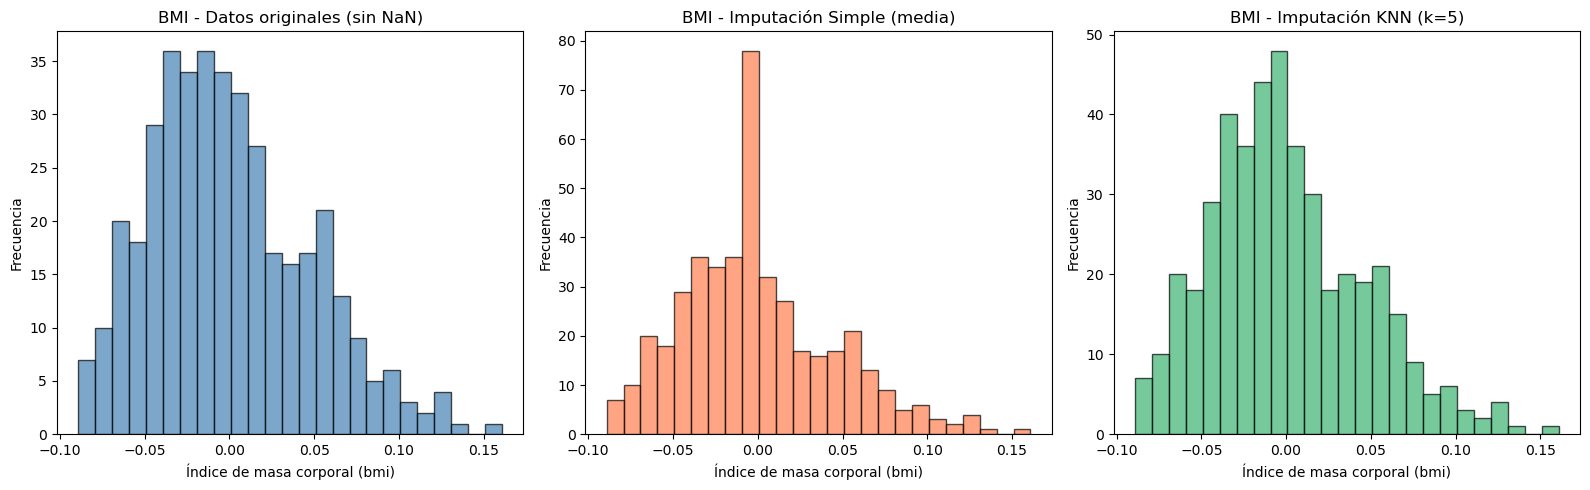

In [8]:
# Histograma comparativo de 'bmi'
figura, ejes = plt.subplots(1, 3, figsize=(16, 5))

ejes[0].hist(datos_antes_imputacion['bmi'].dropna(), bins=25, color='steelblue', edgecolor='black', alpha=0.7)
ejes[0].set_title('BMI - Datos originales (sin NaN)')
ejes[0].set_xlabel('Índice de masa corporal (bmi)')
ejes[0].set_ylabel('Frecuencia')

ejes[1].hist(datos_media['bmi'], bins=25, color='coral', edgecolor='black', alpha=0.7)
ejes[1].set_title('BMI - Imputación Simple (media)')
ejes[1].set_xlabel('Índice de masa corporal (bmi)')
ejes[1].set_ylabel('Frecuencia')

ejes[2].hist(datos_knn['bmi'], bins=25, color='mediumseagreen', edgecolor='black', alpha=0.7)
ejes[2].set_title('BMI - Imputación KNN (k=5)')
ejes[2].set_xlabel('Índice de masa corporal (bmi)')
ejes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En los histogramas se aprecia claramente el efecto de cada método. En la imputación por media noto un pico pronunciado en el centro de la distribución, correspondiente al valor constante asignado a todos los faltantes. En cambio, la imputación KNN produce una distribución más suave y similar a la original, ya que los valores imputados varían según el contexto de cada observación.